In [1]:
#1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import TruncatedSVD

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
#2 Load and filter dataset
df = pd.read_csv(r'C:\Users\sanum\Desktop\recommendation_system\ratings.csv', 
header=None, names=['userId', 'productId', 'rating', 'timestamp'])
df = df.drop('timestamp', axis=1)

# Filter users with at least 50 ratings
user_counts = df.groupby('userId')['rating'].count()
filtered_users = user_counts[user_counts >= 50].index
df_filtered = df[df['userId'].isin(filtered_users)]

# Filter products with at least 10 ratings
product_counts = df_filtered.groupby('productId')['rating'].count()
filtered_products = product_counts[product_counts >= 10].index
df_filtered = df_filtered[df_filtered['productId'].isin(filtered_products)]

print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)
print("Unique users:", df_filtered['userId'].nunique())
print("Unique products:", df_filtered['productId'].nunique())

Original shape: (7824482, 3)
Filtered shape: (42941, 3)
Unique users: 1532
Unique products: 2263


In [3]:
#3Create user product matrix
user_product_matrix = df_filtered.pivot_table(index='userId',columns='productId', values='rating').fillna(0)

print("User Product Matrix shape:", user_product_matrix.shape)
user_product_matrix.head()

User Product Matrix shape: (1532, 2263)


productId,B00001P4XA,B00001P4ZH,B00001WRSJ,B00001ZWXA,B00004SABB,B00004SB92,B00004T8R2,B00004THCZ,B00004WCIC,B00004WCID,...,B00JXVPHC8,B00JY4QCJQ,B00K91DB7Y,B00KJJW36G,B00KNM763E,B00KVNY2KA,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L3YHF6O
userId,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#4 Normalize the User Product Matrix
matrix_normalized= normalize(user_product_matrix)

print("Normalized MatrixShape:", matrix_normalized.shape)
print("Sample Values:", matrix_normalized[0][:10])

Normalized MatrixShape: (1532, 2263)
Sample Values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


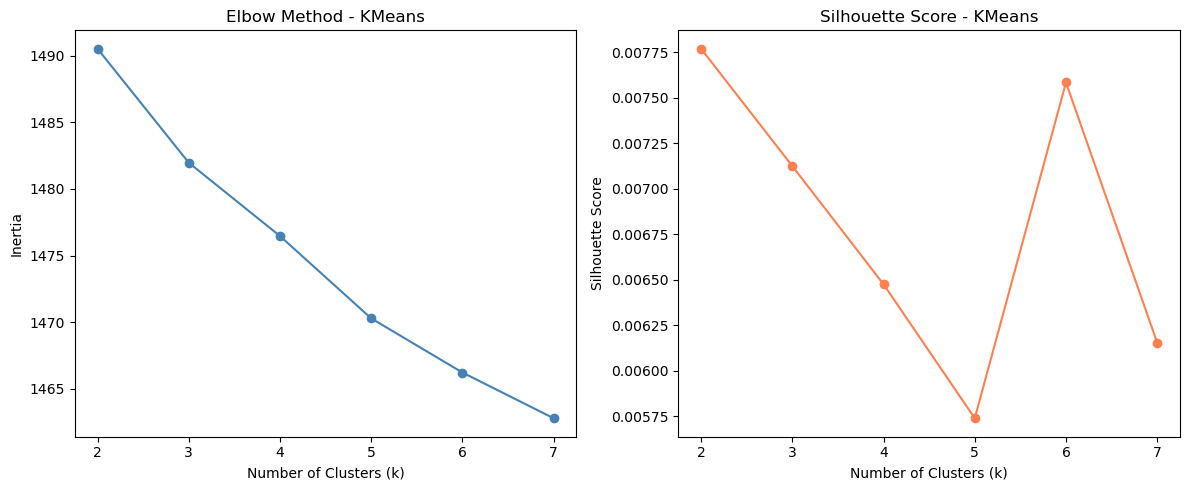


Silhouette Scores: [0.007767962987886575, 0.007123318841510462, 0.00647404674499701, 0.005738214722386345, 0.0075828568520785785, 0.006153187243767785]
Best k: 2


In [5]:
#5 KMeans Clustering
# First find the best number of clusters using Elbow Method
inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(matrix_normalized)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(matrix_normalized, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - KMeans')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.title('Silhouette Score - KMeans')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:", silhouette_scores)
print("Best k:", k_range[silhouette_scores.index(max(silhouette_scores))])

KMeans Cluster DIstribution:
cluster
0    947
1    585
Name: count, dtype: int64


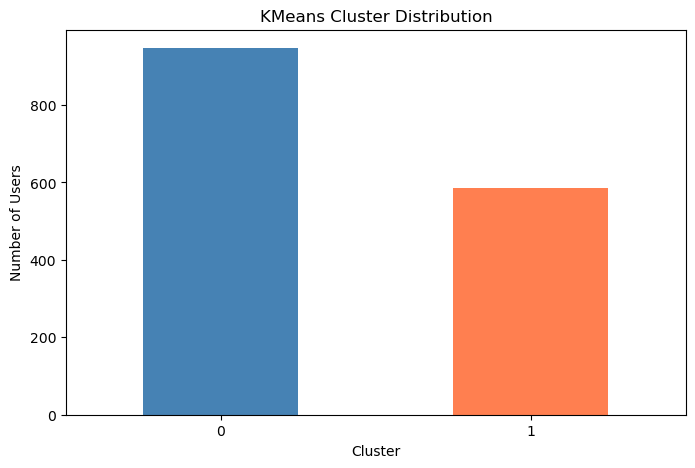

In [7]:
#6 Apply KMeans with the best k=2
best_k=2
kmeans=KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(matrix_normalized)

#Add cluster labels to users
kmeans_clusters= pd.DataFrame({'userId': user_product_matrix.index, 'cluster':
                               kmeans.labels_})

print("KMeans Cluster DIstribution:")
print(kmeans_clusters['cluster'].value_counts())

#Visualizing Clusters
plt.figure(figsize=(8, 5))
kmeans_clusters['cluster'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('KMeans Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.show()

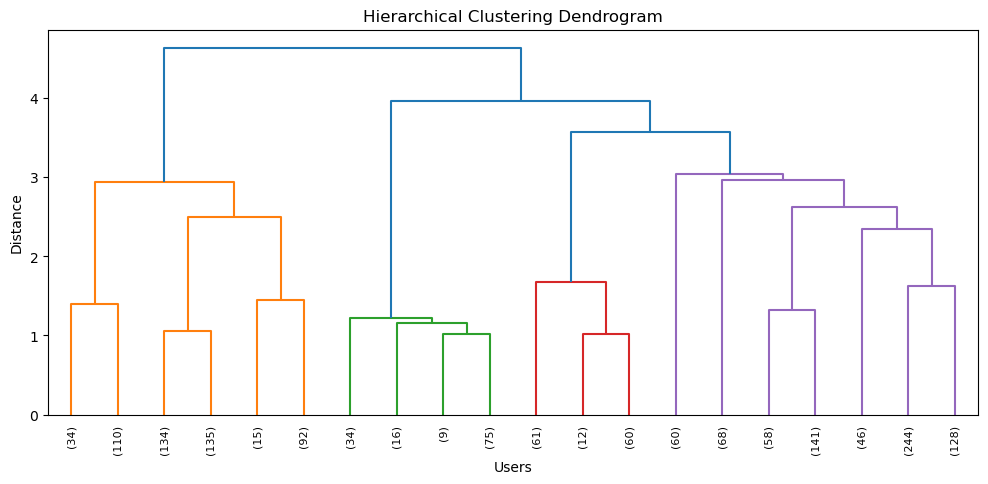

In [8]:
#7 Hierarchical Clustering
from sklearn.decomposition import TruncatedSVD

#Reduce dimensions first for hierarchical clustering 
svd=TruncatedSVD(n_components=10, random_state=42)
matrix_reduced= svd.fit_transform(matrix_normalized)

#Apply Hierarchical clustering
linked= linkage(matrix_reduced, method='ward')

#Plot dendogram
plt.figure(figsize=(12,5))
dendrogram(linked, truncate_mode='lastp', p=20, show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Users')
plt.ylabel('Distance')
plt.show()

Hierarchical Cluster Distribution:
cluster
2    1012
1     520
Name: count, dtype: int64

Hierarchical Clustering Silhouette Score: 0.1440


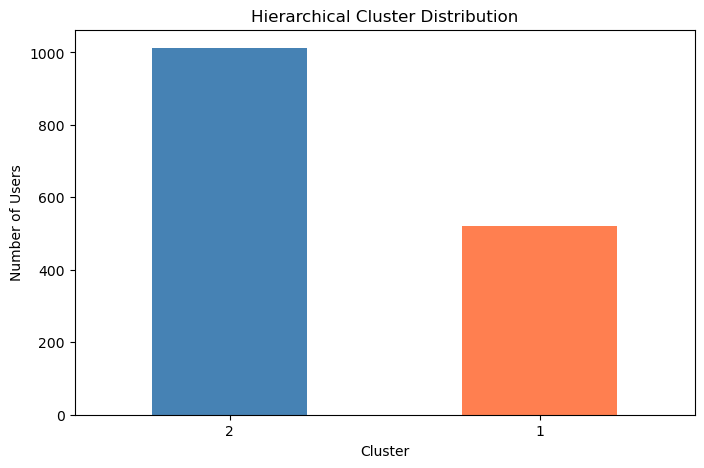

In [9]:
#8 Apply Hierarchical clustering with 2 clusters
hierarchical_labels = fcluster(linked, t=2, criterion='maxclust')

# Add to dataframe
hierarchical_clusters = pd.DataFrame({
    'userId': user_product_matrix.index,
    'cluster': hierarchical_labels
})

print("Hierarchical Cluster Distribution:")
print(hierarchical_clusters['cluster'].value_counts())

# Silhouette score
hier_silhouette = silhouette_score(matrix_reduced, hierarchical_labels)
print(f"\nHierarchical Clustering Silhouette Score: {hier_silhouette:.4f}")

# Visualize
plt.figure(figsize=(8, 5))
hierarchical_clusters['cluster'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Hierarchical Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.show()

DBSCAN Cluster Distribution:
cluster
0    1532
Name: count, dtype: int64

Number of clusters: 1
Number of noise points: 0
DBSCAN found only 1 cluster - cannot calculate silhouette score


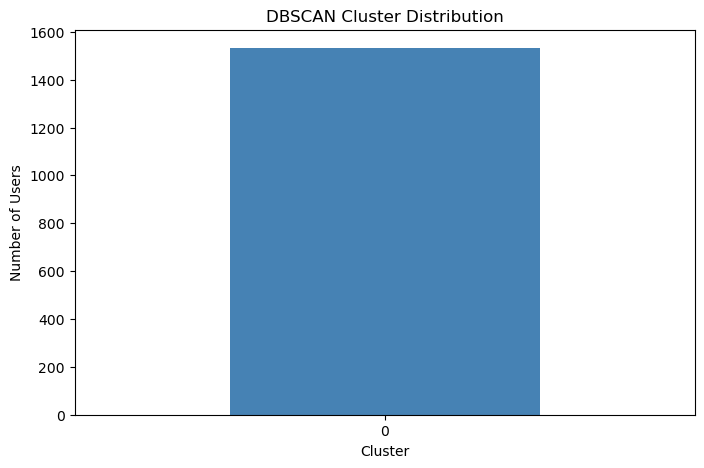

In [10]:
#9 DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(matrix_reduced)

# Add to dataframe
dbscan_clusters = pd.DataFrame({
    'userId': user_product_matrix.index,
    'cluster': dbscan_labels
})

print("DBSCAN Cluster Distribution:")
print(dbscan_clusters['cluster'].value_counts())

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Silhouette score (only if more than 1 cluster found)
if n_clusters > 1:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(matrix_reduced[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")
else:
    dbscan_silhouette = 0
    print("DBSCAN found only 1 cluster - cannot calculate silhouette score")

# Visualize
plt.figure(figsize=(8, 5))
dbscan_clusters['cluster'].value_counts().plot(kind='bar', color='steelblue')
plt.title('DBSCAN Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.show()


In [11]:
#10 Comparative Analysis of all clustering models
comparison = pd.DataFrame({
    'Model': ['KMeans', 'Hierarchical', 'DBSCAN'],
    'Number of Clusters': [2, 2, 1],
    'Silhouette Score': [round(max(silhouette_scores), 4), 
                         round(hier_silhouette, 4), 
                         'N/A'],
    'Noise Points': [0, 0, 0],
    'Suitable for Data': ['Moderate', 'Good', 'Poor']
})

print("Clustering Model Comparison:")
print(comparison.to_string(index=False))

Clustering Model Comparison:
       Model  Number of Clusters Silhouette Score  Noise Points Suitable for Data
      KMeans                   2           0.0078             0          Moderate
Hierarchical                   2            0.144             0              Good
      DBSCAN                   1              N/A             0              Poor


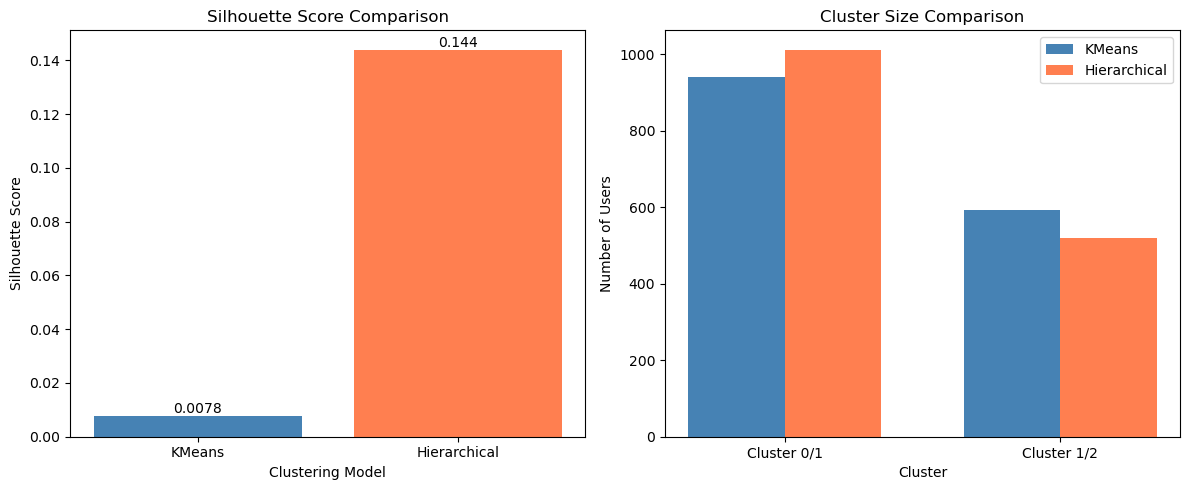

In [12]:
#11 Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Silhouette scores comparison
models = ['KMeans', 'Hierarchical']
scores = [round(max(silhouette_scores), 4), round(hier_silhouette, 4)]

axes[0].bar(models, scores, color=['steelblue', 'coral'])
axes[0].set_title('Silhouette Score Comparison')
axes[0].set_xlabel('Clustering Model')
axes[0].set_ylabel('Silhouette Score')
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.001, str(v), ha='center')

# Cluster distribution comparison
cluster_data = {'KMeans': [940, 592], 'Hierarchical': [1012, 520]}
x = np.arange(2)
width = 0.35

axes[1].bar(x - width/2, cluster_data['KMeans'], width, label='KMeans', color='steelblue')
axes[1].bar(x + width/2, cluster_data['Hierarchical'], width, label='Hierarchical', color='coral')
axes[1].set_title('Cluster Size Comparison')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Users')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Cluster 0/1', 'Cluster 1/2'])
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
#12 Recommendation function using Hierarchical clusters
# (Best performing clustering model)

def get_cluster_recommendations(userId, n=10):
    # Check if user exists
    if userId not in user_product_matrix.index:
        print("User not found!")
        return None
    
    # Get user's cluster from hierarchical clustering
    user_cluster = hierarchical_clusters[
        hierarchical_clusters['userId'] == userId
    ]['cluster'].values[0]
    
    print(f"User {userId} belongs to Cluster {user_cluster}")
    
    # Get all users in same cluster
    cluster_users = hierarchical_clusters[
        hierarchical_clusters['cluster'] == user_cluster
    ]['userId'].values
    
    print(f"Total users in same cluster: {len(cluster_users)}")
    
    # Get ratings from cluster users
    cluster_ratings = user_product_matrix.loc[cluster_users]
    
    # Get products already rated by user
    rated_by_user = user_product_matrix.loc[userId]
    already_rated = rated_by_user[rated_by_user > 0].index
    
    # Calculate mean ratings from cluster
    mean_ratings = cluster_ratings.mean(axis=0)
    
    # Remove already rated products
    recommendations = mean_ratings.drop(already_rated, errors='ignore')
    recommendations = recommendations[recommendations > 0]
    recommendations = recommendations.sort_values(ascending=False).head(n)
    
    return recommendations

# Test with first user
first_user = user_product_matrix.index[0]
print(f"Top 10 recommendations for user: {first_user}")
print("=" * 50)
get_cluster_recommendations(first_user)

Top 10 recommendations for user: A100UD67AHFODS
User A100UD67AHFODS belongs to Cluster 2
Total users in same cluster: 1012


productId
B003ES5ZUU    0.849802
B007WTAJTO    0.732213
B002V88HFE    0.408103
B002WE6D44    0.403162
B000QUUFRW    0.374506
B0019EHU8G    0.374506
B001TH7GUU    0.327075
B005FYNSPK    0.307312
B005CT56F8    0.298419
B0041Q38NU    0.294466
dtype: float64

In [14]:
#13 Model BUilding based on Hierarchical Clusters
#Split data into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_data, test_data=train_test_split(df_filtered, test_size=0.2, random_state=42)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (34352, 3)
Test data shape: (8589, 3)


In [15]:
#14 Model 1 - Popularity Based Model on Clusters
# Get cluster for each user in training data
train_data_with_clusters = train_data.merge(
    hierarchical_clusters, 
    on='userId', 
    how='left'
)

# Calculate popularity within each cluster
cluster_popularity = train_data_with_clusters.groupby(
    ['cluster', 'productId']
)['rating'].agg(['mean', 'count']).reset_index()
cluster_popularity.columns = ['cluster', 'productId', 'avg_rating', 'rating_count']

print("Cluster Popularity Model created!")
print(cluster_popularity.head(10))

Cluster Popularity Model created!
   cluster   productId  avg_rating  rating_count
0        1  B00001P4XA    4.000000             2
1        1  B00001P4ZH    4.750000             4
2        1  B00001WRSJ    4.500000             4
3        1  B00001ZWXA    5.000000             2
4        1  B00004SABB    5.000000             2
5        1  B00004SB92    4.250000             8
6        1  B00004T8R2    4.000000             3
7        1  B00004THCZ    4.333333             3
8        1  B00004WCIC    4.600000             5
9        1  B00004WCID    4.000000             1


In [27]:
#15 Popularity recommendation function based on clusters
def cluster_popularity_recommendations(userId, n=10):
    if userId not in hierarchical_clusters['userId'].values:
        print("User not found!")
        return None
    
    # Get user's cluster
    user_cluster = hierarchical_clusters[
        hierarchical_clusters['userId'] == userId
    ]['cluster'].values[0]
    
    # Get popular products in user's cluster
    cluster_products = cluster_popularity[
        cluster_popularity['cluster'] == user_cluster
    ].sort_values('avg_rating', ascending=False)
    
    # Get products already rated by user
    already_rated = df_filtered[
        df_filtered['userId'] == userId
    ]['productId'].values
    
    # Remove already rated products
    recommendations = cluster_products[
        ~cluster_products['productId'].isin(already_rated)
    ].head(n)
    
    return recommendations[['productId', 'avg_rating', 'rating_count']]

# Test with first user
print(f"Top 10 Popularity recommendations for user {first_user}:")
cluster_popularity_recommendations(first_user)

Top 10 Popularity recommendations for user A100UD67AHFODS:


,productId,avg_rating,rating_count
4391,B00L3YHF6O,5.0,9
3695,B007RZB3KM,5.0,6
3679,B007PG02Q4,5.0,2
2516,B0012Y6HC8,5.0,7
2512,B0012IJYZQ,5.0,7
2509,B0012GK3MQ,5.0,7
2822,B002GP7ZT6,5.0,1
3671,B007KZQM9G,5.0,2
3140,B003ZYF3M8,5.0,9
2496,B0010Z294O,5.0,6


In [ ]:
#16 Model 2 - Collaborative Filtering on Clusters
from sklearn.metrics.pairwise import cosine_similarity

# Create user product matrix from training data only
train_matrix = train_data.pivot_table(
    index='userId',
    columns='productId',
    values='rating'
).fillna(0)

# Calculate user similarity
user_similarity = cosine_similarity(train_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

print("User Similarity Matrix Shape:", user_similarity_df.shape)

User Similarity Matrix Shape: (1531, 1531)


In [ ]:
#17
def cf_cluster_recommendations(userId, n=10):
    if userId not in user_similarity_df.index:
        print("User not found!")
        return None
    
    # Get user's cluster
    user_cluster = hierarchical_clusters[hierarchical_clusters['userId'] == userId]['cluster'].values[0]
    
    # Get users in same cluster WHO ARE ALSO in train_matrix
    cluster_users = hierarchical_clusters[hierarchical_clusters['cluster'] == user_cluster]['userId'].values
    cluster_users = [u for u in cluster_users if u in train_matrix.index]
    
    # Get similar users from same cluster only
    similar_users = user_similarity_df[userId][cluster_users].sort_values(ascending=False)[1:11]
    
    # Get products rated by similar users
    similar_users_products = train_matrix.loc[similar_users.index]
    
    # Get already rated products
    already_rated = train_matrix.loc[userId][train_matrix.loc[userId] > 0].index
    
    # Calculate mean ratings
    mean_ratings = similar_users_products.mean(axis=0)
    recommendations = mean_ratings.drop(already_rated, errors='ignore')
    recommendations = recommendations[recommendations > 0]
    
    return recommendations.sort_values(ascending=False).head(n)

# Test
print(f"Top 10 CF recommendations for {first_user}:")
cf_cluster_recommendations(first_user)

Top 10 CF recommendations for A100UD67AHFODS:


productId
B003LSTD38    1.0
B004G6002M    1.0
B003ES5ZUU    1.0
B001F7AHOG    1.0
B00IUF7VKE    0.9
B007P4VOWC    0.9
B003K1EYM6    0.6
B00004ZCJE    0.5
B007RFW1NA    0.5
B007OY5V68    0.5
dtype: float64

In [ ]:
#18 Model 3 - SVD on Clusters
from sklearn.decomposition import TruncatedSVD

# Apply SVD on train matrix
svd = TruncatedSVD(n_components=10, random_state=42)
matrix_svd = svd.fit_transform(train_matrix)

# Reconstruct matrix
matrix_reconstructed = np.dot(matrix_svd, svd.components_)
predicted_ratings = pd.DataFrame(
    matrix_reconstructed,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print("SVD Model built successfully!")
print("Explained Variance:", round(svd.explained_variance_ratio_.sum(), 4))

SVD Model built successfully!
Explained Variance: 0.07


In [ ]:
#19 SVD recommendation function
def svd_recommendations(userId, n=10):
    if userId not in predicted_ratings.index:
        print("User not found!")
        return None
    
    # Get user's cluster
    user_cluster = hierarchical_clusters[hierarchical_clusters['userId'] == userId]['cluster'].values[0]
    
    # Get predicted ratings for user
    user_predictions = predicted_ratings.loc[userId]
    
    # Get already rated products
    already_rated = train_matrix.loc[userId][train_matrix.loc[userId] > 0].index
    
    # Remove already rated products
    recommendations = user_predictions.drop(already_rated, errors='ignore')
    recommendations = recommendations[recommendations > 0]
    
    print(f"User {userId} belongs to Cluster {user_cluster}")
    return recommendations.sort_values(ascending=False).head(n)

# Test
print(f"Top 10 SVD recommendations for {first_user}:")
svd_recommendations(first_user)

Top 10 SVD recommendations for A100UD67AHFODS:
User A100UD67AHFODS belongs to Cluster 2


productId
B00DTZYHX4    0.618423
B007WTAJTO    0.612060
B007OY5V68    0.576451
B003ES5ZUU    0.570477
B00G4UQ6U8    0.549435
B00FSA8VQ2    0.537439
B000JMJWV2    0.506235
B0079UAT0A    0.456849
B00DK2JQOQ    0.451376
B002WE6D44    0.436270
Name: A100UD67AHFODS, dtype: float64

In [ ]:
#20 Evaluate all 3 models using RMSE
from sklearn.metrics import mean_squared_error

test_users = test_data['userId'].values
test_products = test_data['productId'].values
test_ratings = test_data['rating'].values

# SVD predictions
svd_preds = []
for user, product in zip(test_users, test_products):
    if user in predicted_ratings.index and product in predicted_ratings.columns:
        svd_preds.append(predicted_ratings.loc[user, product])
    else:
        svd_preds.append(df_filtered['rating'].mean())

svd_rmse = np.sqrt(mean_squared_error(test_ratings, svd_preds))

# Popularity baseline RMSE
popularity_preds = [df_filtered['rating'].mean()] * len(test_ratings)
popularity_rmse = np.sqrt(mean_squared_error(test_ratings, popularity_preds))

print(f"Popularity Model RMSE: {popularity_rmse:.4f}")
print(f"SVD Model RMSE: {svd_rmse:.4f}")
print(f"\nBetter model: {'SVD' if svd_rmse < popularity_rmse else 'Popularity'}")

Popularity Model RMSE: 0.9713
SVD Model RMSE: 4.2488

Better model: Popularity


In [ ]:
#21 Fix SVD predictions - clip values to valid rating range 1-5
svd_preds_fixed = []
for user, product in zip(test_users, test_products):
    if user in predicted_ratings.index and product in predicted_ratings.columns:
        pred = predicted_ratings.loc[user, product]
        # Clip prediction between 1 and 5
        pred = max(1.0, min(5.0, pred))
        svd_preds_fixed.append(pred)
    else:
        svd_preds_fixed.append(df_filtered['rating'].mean())

svd_rmse_fixed = np.sqrt(mean_squared_error(test_ratings, svd_preds_fixed))

print(f"Popularity Model RMSE: {popularity_rmse:.4f}")
print(f"SVD Model RMSE (fixed): {svd_rmse_fixed:.4f}")
print(f"\nBetter model: {'SVD' if svd_rmse_fixed < popularity_rmse else 'Popularity'}")

Popularity Model RMSE: 0.9713
SVD Model RMSE (fixed): 3.4306

Better model: Popularity


In [ ]:
#22 Rebuild SVD with more components
svd_better = TruncatedSVD(n_components=50, random_state=42)
matrix_svd_better = svd_better.fit_transform(train_matrix)
matrix_reconstructed_better = np.dot(matrix_svd_better, svd_better.components_)

predicted_ratings_better = pd.DataFrame(
    matrix_reconstructed_better,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print("Explained Variance with 50 components:", round(svd_better.explained_variance_ratio_.sum(), 4))

# Recalculate RMSE
svd_preds_better = []
for user, product in zip(test_users, test_products):
    if user in predicted_ratings_better.index and product in predicted_ratings_better.columns:
        pred = predicted_ratings_better.loc[user, product]
        pred = max(1.0, min(5.0, pred))
        svd_preds_better.append(pred)
    else:
        svd_preds_better.append(df_filtered['rating'].mean())

svd_rmse_better = np.sqrt(mean_squared_error(test_ratings, svd_preds_better))

print(f"\nPopularity Model RMSE: {popularity_rmse:.4f}")
print(f"SVD Model RMSE (50 components): {svd_rmse_better:.4f}")
print(f"Better model: {'SVD' if svd_rmse_better < popularity_rmse else 'Popularity'}")

Explained Variance with 50 components: 0.2052

Popularity Model RMSE: 0.9713
SVD Model RMSE (50 components): 3.4346
Better model: Popularity


Final Model Comparison:
                  Model                 Type    RMSE Personalised        Best For
       Popularity Based     Non-Personalised  0.9713           No       New users
Collaborative Filtering        Cluster Based     N/A          Yes    Active users
                    SVD Matrix Factorization  3.4346          Yes Pattern finding


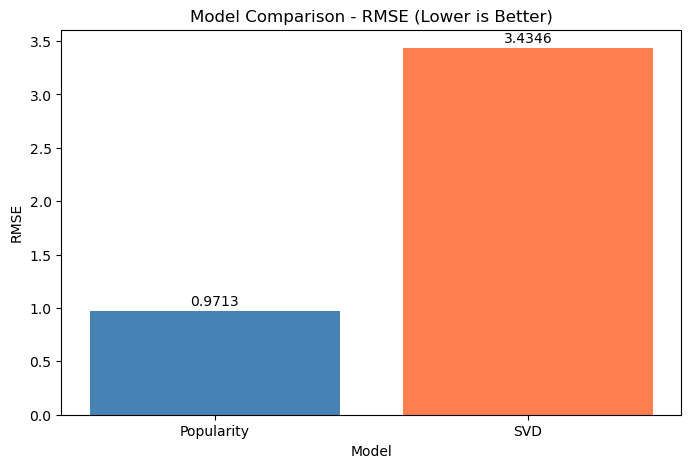

In [ ]:
#23 Final Comparative Analysis
results = pd.DataFrame({
    'Model': ['Popularity Based', 'Collaborative Filtering', 'SVD'],
    'Type': ['Non-Personalised', 'Cluster Based', 'Matrix Factorization'],
    'RMSE': [round(popularity_rmse, 4), 'N/A', round(svd_rmse_better, 4)],
    'Personalised': ['No', 'Yes', 'Yes'],
    'Best For': ['New users', 'Active users', 'Pattern finding']
})

print("Final Model Comparison:")
print(results.to_string(index=False))

# Visualization
plt.figure(figsize=(8, 5))
models = ['Popularity', 'SVD']
rmse_values = [popularity_rmse, svd_rmse_better]
bars = plt.bar(models, rmse_values, color=['steelblue', 'coral'])
plt.title('Model Comparison - RMSE (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('RMSE')
for bar, val in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.05, 
             str(round(val, 4)), 
             ha='center')
plt.show()
